Importação das bibliotecas

In [ ]:
!pip install pandas scikit-learn ucimlrepo

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
try:
    zoo = fetch_ucirepo(id=111)
    X_original_df = zoo.data.features
    y_original_df = zoo.data.targets

    print("Colunas do dataset original:")
    print(X_original_df.head())
    print("\nTipos de animais do dataset original:")
    print(y_original_df.head())
    print(f"\nForma das quantidades originais: {X_original_df.shape}")
    print(f"Forma dos alvos originais: {y_original_df.shape}")

    # Check para valores faltando
    print("\nValores faltando no dataset original:")
    print(X_original_df.isnull().sum())
    print("\nValores faltando nos dados alvo:")
    print(y_original_df.isnull().sum())

    y_original = y_original_df.iloc[:, 0].values

except Exception as e:
    print(f"Erro ao processar o dataset: {e}")
    #Baixe diretamente do site
    #https://archive.ics.uci.edu/dataset/111/zoo
    #e dê upload usando pandas, e.g.:
    #column_names = ["animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic", "predator", "toothed", "backbone", "breathes", "venomous", "fins", "legs", "tail", "domestic", "catsize", "type"]
    #data = pd.read_csv('zoo.data', header=None, names=column_names)
    #X_original_df = data.drop(columns=['animal_name', 'type'])
    #y_original = data['type'].values
    #print("Loaded data manually as a fallback.")
    #print(X_original_df.head())

Colunas do dataset original:
   hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  backbone  \
0     1         0     0     1         0        0         1        1         1   
1     1         0     0     1         0        0         0        1         1   
2     0         0     1     0         0        1         1        1         1   
3     1         0     0     1         0        0         1        1         1   
4     1         0     0     1         0        0         1        1         1   

   breathes  venomous  fins  legs  tail  domestic  catsize  
0         1         0     0     4     0         0        1  
1         1         0     0     4     1         0        1  
2         0         0     1     0     1         0        0  
3         1         0     0     4     0         0        1  
4         1         0     0     4     1         0        1  

Tipos de animais do dataset original:
   type
0     1
1     1
2     4
3     1
4     1

Forma das quantidades originai

Nosso dataset possui 101 animais diferentes separados em 7 classes, com 16 atributos diferentes para cada animal

Primeiro passo é realizar a remoção das colunas "pelos" e "penas"

In [ ]:
#Identificar as colunas que vamos remover
columns_to_remove = ['hair', 'feathers']

#Criar o dataset modificado
X_modified_df = X_original_df.drop(columns=columns_to_remove, errors='ignore')

print("\nDataset modificado(depois de remover 'hair', 'feathers'):")
print(X_modified_df.head())
print(f"\nForma após as modificações: {X_modified_df.shape}")




Dataset modificado(depois de remover 'hair', 'feathers'):
   eggs  milk  airborne  aquatic  predator  toothed  backbone  breathes  \
0     0     1         0        0         1        1         1         1   
1     0     1         0        0         0        1         1         1   
2     1     0         0        1         1        1         1         0   
3     0     1         0        0         1        1         1         1   
4     0     1         0        0         1        1         1         1   

   venomous  fins  legs  tail  domestic  catsize  
0         0     0     4     0         0        1  
1         0     0     4     1         0        1  
2         0     1     0     1         0        0  
3         0     0     4     0         0        1  
4         0     0     4     1         0        1  

Forma após as modificações: (101, 14)


Para as classificações solicitadas, iremos utilizar Random Forest e K-Means

Treinamos o modelo com 70% e usamos 30% para os testes
Após o treinamento, o modelo realiza predições com os dados de teste. A seguir mostramos:

A classificação (classification report), com métricas como precisão, recall e F1-score.

E a matriz de confusão, que mostra a distribuição real vs. predita das classes.

In [ ]:
#Para o dataset original
print("--- Classificação: Dataset Original ---")
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_original_df, y_original, test_size=0.3, random_state=42, stratify=y_original)

#Inicializando o treinamento com Random Forest
rf_classifier_orig = RandomForestClassifier(n_estimators=101, random_state=42, max_depth=5, min_samples_split=5)
print(f"\nParametros do Random Forest para o dataset original: {rf_classifier_orig.get_params()}")
rf_classifier_orig.fit(X_train_orig, y_train_orig)

#Previsões usando o dataset original.
y_pred_orig = rf_classifier_orig.predict(X_test_orig)

#Avaliação com Classification Report e Matriz de Confusão no Dataset Original
print("\nClassificação(Dataset Original):")
print(classification_report(y_test_orig, y_pred_orig, zero_division=0))
print("\nMatriz de confusão(Dataset Original):")
print(confusion_matrix(y_test_orig, y_pred_orig))

#Para o dataset modificado
print("\n--- Classificação: Dataset Modificado ---")
X_train_mod, X_test_mod, y_train_mod, y_test_mod = train_test_split(X_modified_df, y_original, test_size=0.3, random_state=42, stratify=y_original)

#Incializando e treinando com Random Forest
rf_classifier_mod = RandomForestClassifier(n_estimators=101, random_state=42, max_depth=5, min_samples_split=5)
print(f"\nParametros do Random Forest para Dataset Modificado: {rf_classifier_mod.get_params()}")
rf_classifier_mod.fit(X_train_mod, y_train_mod)

#Predições utilizando o dataset Modificado
y_pred_mod = rf_classifier_mod.predict(X_test_mod)

#Avaliações Classification Report e Matriz de Confusão no Dataset Modificado
print("\nClassificação(Dataset Modificado):")
print(classification_report(y_test_mod, y_pred_mod, zero_division=0))
print("\nMatriz de confusão(Dataset Modificado):")
print(confusion_matrix(y_test_mod, y_pred_mod))

--- Classificação: Dataset Original ---

Parametross do Random Forest para o dataset original: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 90, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Classificação(Dataset Original):
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6
           3       1.00      0.50      0.67         2
           4       0.80      1.00      0.89         4
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy               

Será feita a comparação visual e gráfica do desempenho do Random Forest nos dois datasets usando matrizes de confusão.



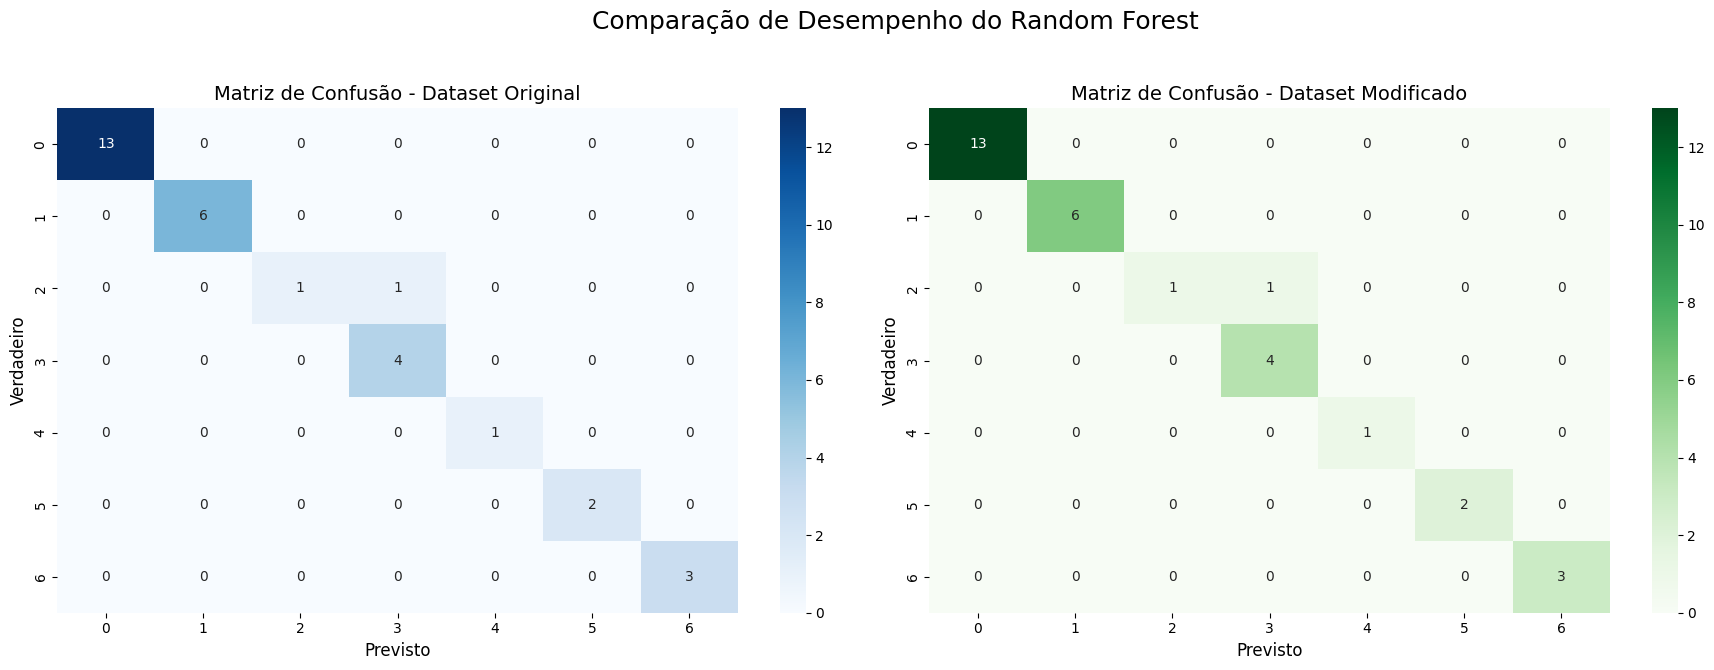

In [ ]:
cm_orig = confusion_matrix(y_test_orig, y_pred_orig)
cm_mod = confusion_matrix(y_test_mod, y_pred_mod)

# --- Criar o Gráfico Comparativo ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico para o Dataset Original
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão - Dataset Original', fontsize=14)
axes[0].set_xlabel('Previsto', fontsize=12)
axes[0].set_ylabel('Verdadeiro', fontsize=12)

# Gráfico para o Dataset Modificado
sns.heatmap(cm_mod, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusão - Dataset Modificado', fontsize=14)
axes[1].set_xlabel('Previsto', fontsize=12)
axes[1].set_ylabel('Verdadeiro', fontsize=12)

plt.suptitle('Comparação de Desempenho do Random Forest', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

A partir desta etapa, seguimos do aprendizado supervisionado do Random Forest para o não-supervisionado utilizando o algoritmo K-Means para realizar clustering nos dados.

In [ ]:
#Treinamento com k-means, configurado para obter 7 clusters, o mesmo número de classes originais
#Para o dataset original
print("\n--- Clustering: Dataset Original ---")

kmeans_orig = KMeans(n_clusters=7, random_state=42, n_init=10)
print(f"\nParametros do K-Means para o dataset original: {kmeans_orig.get_params()}")
clusters_orig = kmeans_orig.fit_predict(X_original_df)

#Avaliação usando Silhouette Score
try:
    silhouette_avg_orig = silhouette_score(X_original_df, clusters_orig)
    print(f"Silhouette Score (Dataset Original): {silhouette_avg_orig:.4f}")
except ValueError as e:
    print(f"Não foi possível calcular o Silhouette Score para o dataset original(neceessita que >1 cluster e < n_amostras-1 clusters): {e}")


#Para o dataset modificado
print("\n--- Clustering: Dataset Modificado ---")
kmeans_mod = KMeans(n_clusters=7, random_state=42, n_init=10)
print(f"\nParametros do K-Means para o dataset modificado: {kmeans_mod.get_params()}")
clusters_mod = kmeans_mod.fit_predict(X_modified_df)

#Avaliação do dataset modificado usando Silhouette Score
try:
    silhouette_avg_mod = silhouette_score(X_modified_df, clusters_mod)
    print(f"Silhouette Score (Dataset modificado): {silhouette_avg_mod:.4f}")
except ValueError as e:
    print(f"Não foi possível calcular o Silhouette Score para o Dataset modificado: {e}")


--- Clustering: Dataset Original ---

Parametros do K-Means para o dataset original: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 7, 'n_init': 10, 'random_state': 42, 'tol': 0.0001, 'verbose': 0}
Silhouette Score (Dataset Original): 0.4313

--- Clustering: Dataset Modificado ---

Parametros do K-Means para o dataset modificado: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 7, 'n_init': 10, 'random_state': 42, 'tol': 0.0001, 'verbose': 0}
Silhouette Score (Dataset modificado): 0.4147


Sobre o Silhouette Score -

Ele mede o quão semelhante um objeto é ao seu próprio cluster em comparação com outros clusters. A pontuação varia de -1 a 1, onde um valor alto indica um bom agrupamento.

Próximo de +1: Indica que o ponto de dado está longe dos clusters vizinhos e bem agrupado em seu próprio cluster. Isso é o ideal. Próximo de 0: Indica que o ponto de dado está na fronteira ou muito próximo da fronteira de decisão entre dois clusters. Próximo de -1: Indica que o ponto de dado pode ter sido atribuído ao cluster errado, pois está mais próximo de um cluster vizinho do que do seu próprio.

A seguir, comparamos visualmente a qualidade dos agrupamentos formados pelo K-Means com o dataset original e o com o dataset modificado.

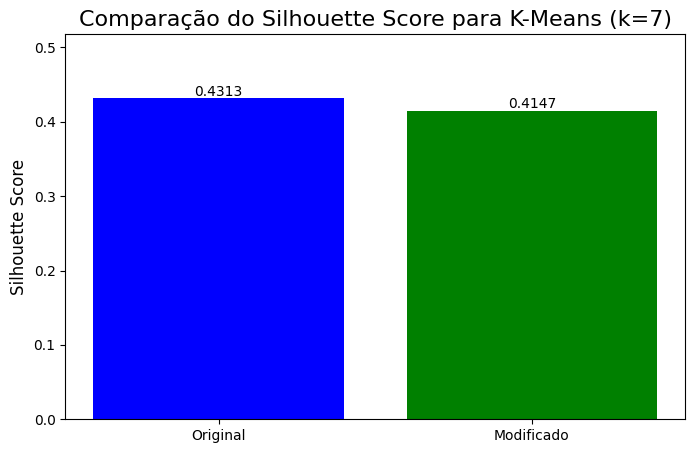

In [ ]:
# Cálculo do Silhouette Score
silhouette_avg_orig = silhouette_score(X_original_df, clusters_orig)
silhouette_avg_mod = silhouette_score(X_modified_df, clusters_mod)

scores = {'Original': silhouette_avg_orig, 'Modificado': silhouette_avg_mod}
datasets = list(scores.keys())
values = list(scores.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(datasets, values, color=['blue', 'green'])

# Adicionar o valor em cima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom', ha='center')

plt.title('Comparação do Silhouette Score para K-Means (k=7)', fontsize=16)
plt.ylabel('Silhouette Score', fontsize=12)
plt.ylim(0, max(values) * 1.2)
plt.show()

Uma tabela de contingência pode ajudar a comparar quantos itens de cada classe real caíram em cada cluster que o K-Means previu.

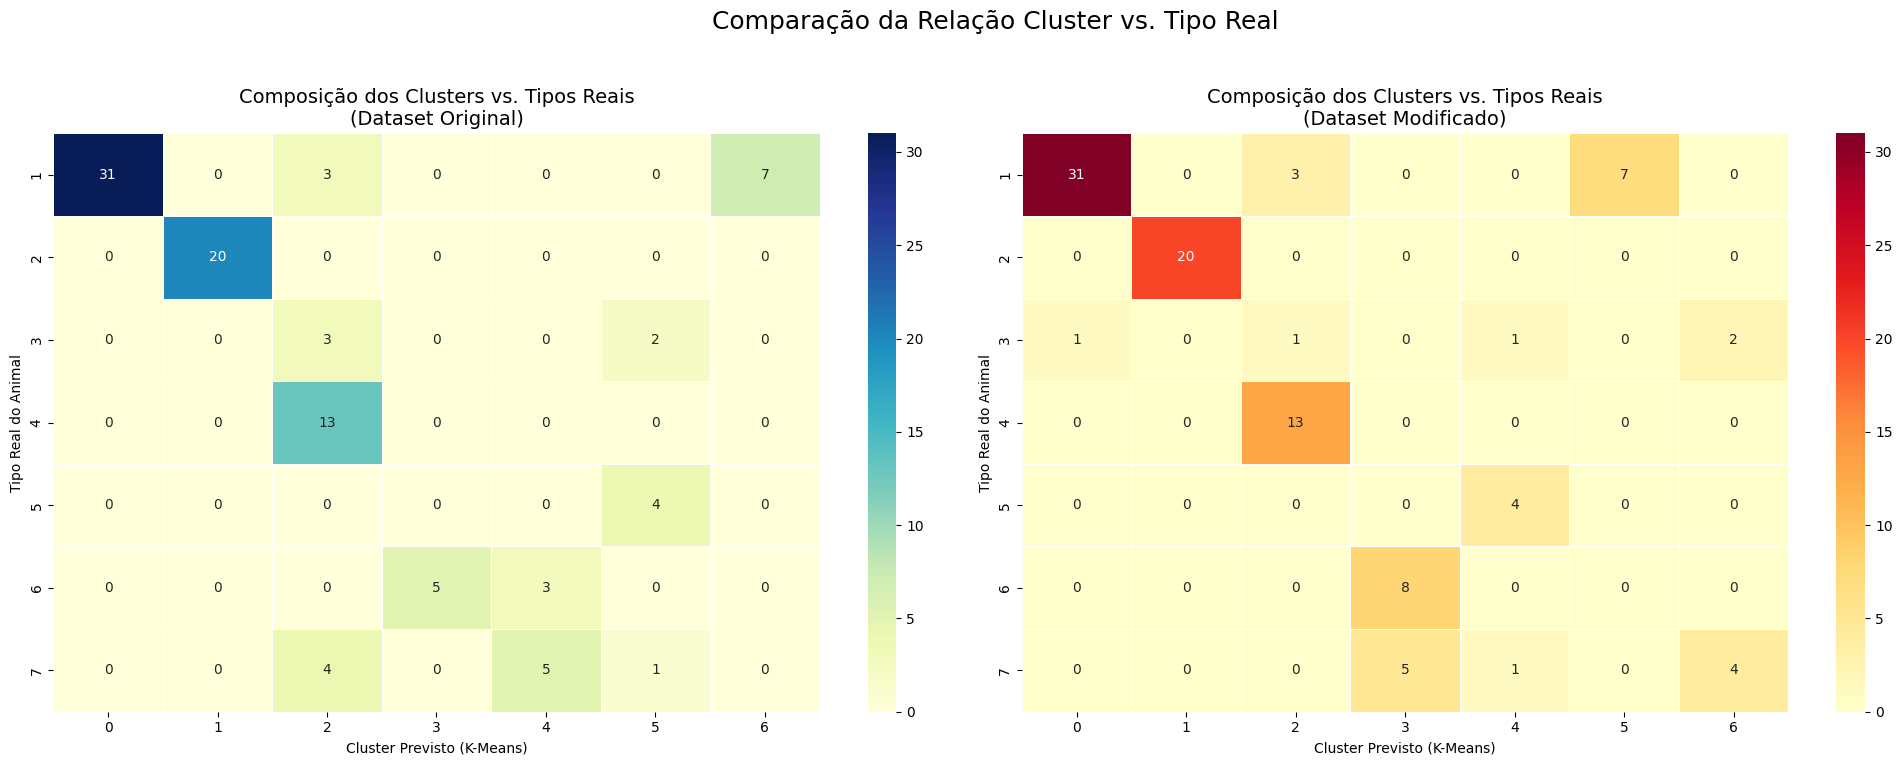

In [ ]:
# --- Tabela de Contingência (Crosstab) e Heatmap ---

# Criar a tabela de contingência para o dataset original
# A tabela mostra quantos animais de cada tipo 'real' caíram em cada 'cluster'
contingency_table_orig = pd.crosstab(y_original, clusters_orig)
# Adicionar nomes às colunas e índices para clareza
contingency_table_orig.index.name = 'Tipo Real do Animal'
contingency_table_orig.columns.name = 'Cluster Previsto (K-Means)'


# Criar a tabela de contingência para o dataset modificado
contingency_table_mod = pd.crosstab(y_original, clusters_mod)
contingency_table_mod.index.name = 'Tipo Real do Animal'
contingency_table_mod.columns.name = 'Cluster Previsto (K-Means)'


# --- Criar o Gráfico Comparativo ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap para o Dataset Original
sns.heatmap(contingency_table_orig, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0], linewidths=.5)
axes[0].set_title('Composição dos Clusters vs. Tipos Reais\n(Dataset Original)', fontsize=14)


# Heatmap para o Dataset Modificado
sns.heatmap(contingency_table_mod, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], linewidths=.5)
axes[1].set_title('Composição dos Clusters vs. Tipos Reais\n(Dataset Modificado)', fontsize=14)

plt.suptitle('Comparação da Relação Cluster vs. Tipo Real', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Podemos calcular o silhouette score com n número de clusters

In [ ]:
#Podemos testar com valores diferentes de n_clusters
# for n_c in range(2, 11):
#     kmeans_test = KMeans(n_clusters=n_c, random_state=42, n_init=10)
#     clusters_test = kmeans_test.fit_predict(X_original_df)
#     if len(np.unique(clusters_test)) > 1:
#         score = silhouette_score(X_original_df, clusters_test)
#         print(f"Para n_clusters = {n_c} (Original), Silhouette Score = {score:.4f}")
#     else:
#         print(f"Para n_clusters = {n_c} (Original), apenas 1 cluster achado.")

# for n_c in range(2, 11):
#     kmeans_test_mod = KMeans(n_clusters=n_c, random_state=42, n_init=10)
#     clusters_test_mod = kmeans_test_mod.fit_predict(X_modified_df)
#     if len(np.unique(clusters_test_mod)) > 1:
#          score_mod = silhouette_score(X_modified_df, clusters_test_mod)
#          print(f"Para n_clusters = {n_c} (Modificado), Silhouette Score = {score_mod:.4f}")
#     else:
#         print(f"Para n_clusters = {n_c} (Modificado), apenas 1 cluster achado.")

Para n_clusters = 2 (Original), Silhouette Score = 0.4186
Para n_clusters = 3 (Original), Silhouette Score = 0.4150
Para n_clusters = 4 (Original), Silhouette Score = 0.4572
Para n_clusters = 5 (Original), Silhouette Score = 0.4269
Para n_clusters = 6 (Original), Silhouette Score = 0.4468
Para n_clusters = 7 (Original), Silhouette Score = 0.4313
Para n_clusters = 8 (Original), Silhouette Score = 0.4454
Para n_clusters = 9 (Original), Silhouette Score = 0.4149
Para n_clusters = 10 (Original), Silhouette Score = 0.3581
Para n_clusters = 2 (Modificado), Silhouette Score = 0.4242
Para n_clusters = 3 (Modificado), Silhouette Score = 0.4178
Para n_clusters = 4 (Modificado), Silhouette Score = 0.4377
Para n_clusters = 5 (Modificado), Silhouette Score = 0.4061
Para n_clusters = 6 (Modificado), Silhouette Score = 0.4150
Para n_clusters = 7 (Modificado), Silhouette Score = 0.4147
Para n_clusters = 8 (Modificado), Silhouette Score = 0.4243
Para n_clusters = 9 (Modificado), Silhouette Score = 0.42

Comparação e análise dos resultados obtidos

Comparação do dataset original com o método Random Forest

A razão para os resultados idênticos é a alta redundância de informações entre os atributos do dataset. Certos atributos são substitutos quase perfeitos para outros.

Um exemplo que podemos citar é os atributos hair e milk, que praticamente todos os animais no dataset que têm hair=1 (mamíferos) também têm milk=1. O Random Forest é um modelo poderoso o suficiente para aprender essa correlação perfeitamente. Quando você remove o atributo hair, o modelo simplesmente passa a usar o atributo milk para tomar a mesma decisão que tomaria antes e identificar os mamíferos com a mesma precisão. Assim, a informação, na prática, não é perdida. O mesmo vale para os atributos feather e eggs.

Assim, chegamos a conclusão que o resultado idêntico mostra que, para este problema específico, os atributos hair e feathers não continham informações únicas que não pudessem ser inferidas a partir dos outros atributos. Em um dataset mais complexo e com menos correlações perfeitas, teríamos resultados diferentes gerados.

Comparação do dataset original com o método K-Means

O impacto no modelo de agrupamento K-Means foi menos direto e é avaliado pelo Silhouette Score, que mede quão bem definidos e separados os clusters são. O dataset original produziu um certo Silhouette Score. Esse valor representa a qualidade da estrutura dos clusters quando todos os atributos, incluindo 'hair' e 'feathers', são considerados para calcular as distâncias entre os pontos de dados. Em comparação, o Silhouette Score no dataset modificado diminuiu. A remoção de 'hair' e 'feathers' significa que duas dimensões importantes, que ajudavam a separar naturalmente grupos como mamíferos e aves, foram perdidas. Sem esses atributos, a "distância" geométrica entre esses animais e outros grupos ficou menor, tornando os clusters menos densos e mais sobrepostos.

Chegamos à conclusão de que a remoção dos atributos piorou a qualidade do agrupamento. Diferente da classificação, o K-Means não "sabe" que o atributo hair é importante para mamíferos. Ele apenas trata esse atributo como mais uma dimensão no espaço de dados. Como essa dimensão ajudava a separar os dados em grupos distintos, sua remoção tornou a tarefa de encontrar uma estrutura de agrupamento coesa e bem separada mais difícil.